In [ ]:
import numpy as np
import pandas as pd
import sympy as sm
from scipy.stats import gamma

import os
import sys

# Standard interactive replacement for the 'parent directory' hack
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from utils import remove_cycles, mat_from_np, move_scattered_identity
from PPRCalculator import PPRCalculator

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Models

### Toy Model #1 (Paper)

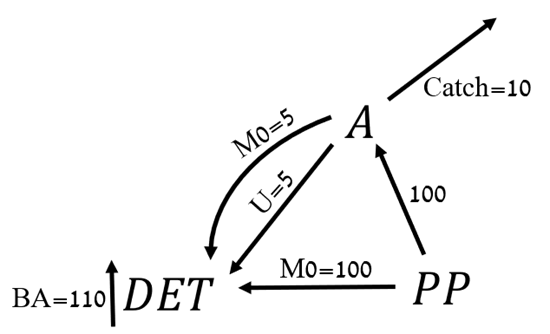

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0],
    1: [0, 0, 0],
    2: [100, 0, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular']
groups_df['q'] = [200, 110, 100]
groups_df['p'] = [200, 110, 15]
groups_df['catch'] = [0, 0, 10]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 110, 0]
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [100, 0, 5]
groups_df['egestion'] = [0, 0, 5]
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

### Toy Model #2 (Paper)

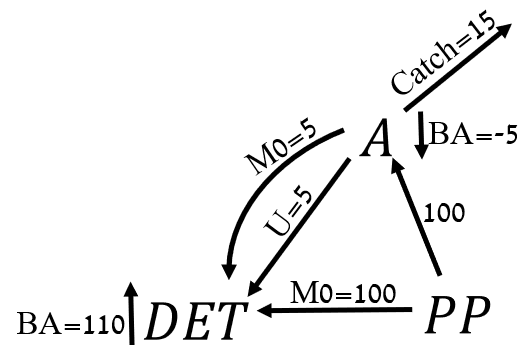

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0],
    1: [0, 0, 0],
    2: [100, 0, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular']
groups_df['q'] = [200, 110, 100]
groups_df['p'] = [200, 110, 15]
groups_df['catch'] = [0, 0, 15]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 110, -5]
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [100, 0, 5]
groups_df['egestion'] = [0, 0, 5]
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

In [ ]:
self.get_TE(TE_option='TE', as_matrix=False).rename(self.seq2name)

### Toy Model #3 (Paper)

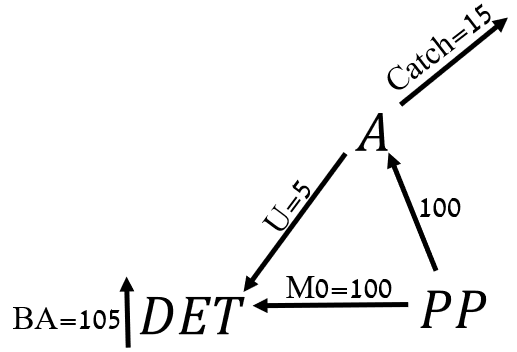

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0],
    1: [0, 0, 0],
    2: [100, 0, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular']
groups_df['q'] = [200, 105, 100]
groups_df['p'] = [200, 105, 15]
groups_df['catch'] = [0, 0, 15]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 105, 0]
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [100, 0, 0]
groups_df['egestion'] = [0, 0, 5]
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

In [ ]:
sppr, A, L = self.SPPR_new(TE=None, TE_option='GE', DET_TE_vals=1)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
# sppr.sum(axis=1)
sppr

### Toy Model #1

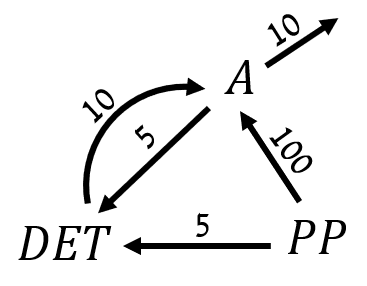

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0],
    1: [0, 0, 0],
    2: [100, 10, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular']
groups_df['q'] = [105, 10, 110]
groups_df['p'] = [105, 10, 15]
groups_df['catch'] = [0, 0, 10]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = 0
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [5, 0, 5]
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

same but reversed sequences:

In [ ]:
Z = pd.DataFrame({
    2: [0, 0, 0],
    1: [0, 0, 0],
    0: [0, 10, 100]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    2: 'PP',
    1: 'DET',
    0: 'A'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['A', 'DET', 'PP']
groups_df['trophic_info'] = ['Regular', 'DET', 'PP']
groups_df['q'] = [110, 10, 105]
groups_df['p'] = [15, 10, 105]
groups_df['catch'] = [10, 0, 0]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = 0
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [5, 0, 5]
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

### Toy Model #2

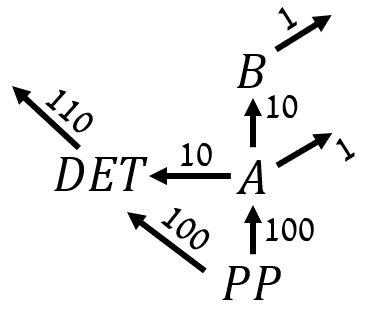

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0],
    1: [0, 0, 0, 0],
    2: [100, 0, 0, 0],
    3: [0, 0, 10, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A',
    3: 'B'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular']
groups_df['q'] = [200, 110, 100, 10]
groups_df['p'] = [200, 110, 21, 1]
groups_df['catch'] = [0, 0, 1, 1]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 55, 0, 0]  # DET excess goes 1/2 to immigration and 1/2 to growth
groups_df['immigration'] = 0
groups_df['emigration'] = [0, 55, 0, 0] # DET excess goes 1/2 to immigration and 1/2 to growth
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [100, 0, 10, 0]
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

### Toy Model #3

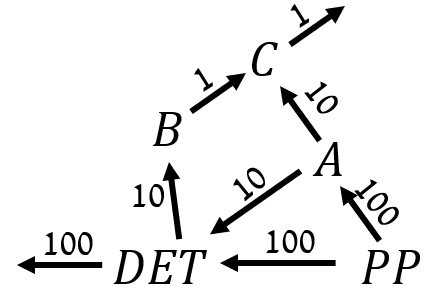

In [ ]:
Z = pd.DataFrame({
    0: [0,   0,  0,  0, 0],
    1: [0,   0,  0,  0, 0],
    2: [100, 0,  0,  0, 0],
    3: [0,   10, 0,  0, 0],
    4: [0,   0,  10, 1, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A',
    3: 'B',
    4: 'C'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B', 'C']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular', 'Regular']
groups_df['q'] = [200, 110, 100, 10, 11]
groups_df['p'] = [200, 110, 20, 1, 1]
groups_df['catch'] = [0, 0, 0, 0, 1]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 50, 0, 0, 0]  # DET excess goes 1/2 to emmigration and 1/2 to growth
groups_df['immigration'] = 0
groups_df['emigration'] = [0, 50, 0, 0, 0]  # DET excess goes 1/2 to emmigration and 1/2 to growth
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [100, 0, 10, 0, 0]
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

### Toy Model #4 (2 types of PP)

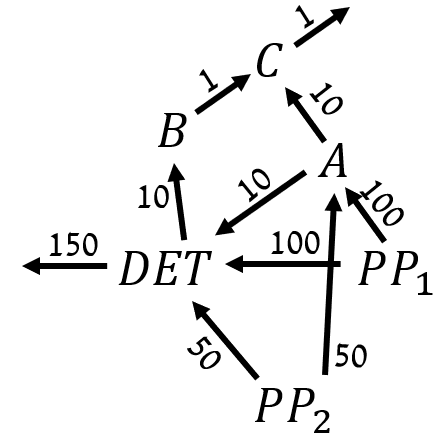

In [ ]:
Z = pd.DataFrame({
    #   PP1 PP2 DET A  B  C
    0: [0,  0,  0,  0, 0, 0],  # PP1
    1: [0,  0,  0,  0, 0, 0],  # PP2
    2: [0, 0, 0, 0, 0, 0],  # DET
    3: [100, 50, 0, 0, 0, 0],  # A
    4: [0,  0,  10,  0, 0, 0],  # B
    5: [0,  0,  0,  10, 1, 0],  # C
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP1',
    1: 'PP2',
    2: 'DET',
    3: 'A',
    4: 'B',
    5: 'C',
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP1', 'PP2', 'DET', 'A', 'B', 'C']
groups_df['trophic_info'] = ['PP', 'PP', 'DET', 'Regular', 'Regular', 'Regular']
groups_df['q'] = [200, 100, 160, 150, 10, 11]
groups_df['p'] = [200, 100, 160, 20, 1, 1]
groups_df['catch'] = [0, 0, 0, 0, 0, 1]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 0, 75, 0, 0, 0]  # DET excess goes 1/2 to emigration and 1/2 to growth
groups_df['immigration'] = 0  
groups_df['emigration'] = [0, 0, 75, 0, 0, 0]  # DET excess goes 1/2 to emigration and 1/2 to growth
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [100, 50, 0, 10, 0, 0]
groups_df['egestion'] = 0
groups_df['flow_to_det'] = groups_df['egestion'] + groups_df['M0']
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

### Toy Model #5 (includes egestion)

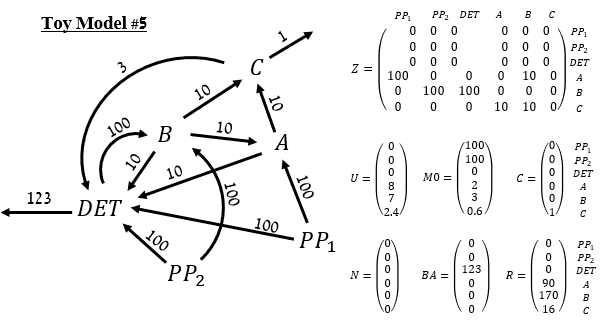

In [ ]:
Z = pd.DataFrame({
    #  PP1 PP2   DET  A   B   C
    0: [0,   0,    0,  0,  0,  0],   # PP1
    1: [0,   0,    0,  0,  0,  0],   # PP2
    2: [0,   0,    0,  0,  0,  0],   # DET
    3: [100, 0,    0,  0,  10, 0],   # A
    4: [0,   100, 100, 0,  0,  0],   # B
    5: [0,   0,    0,  10, 10, 0],   # C
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP1',
    1: 'PP2',
    2: 'DET',
    3: 'A',
    4: 'B',
    5: 'C',
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP1', 'PP2', 'DET', 'A', 'B', 'C']
groups_df['trophic_info'] = ['PP', 'PP', 'DET', 'Regular', 'Regular', 'Regular']
groups_df['catch'] = [0, 0, 0, 0, 0, 1]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()

groups_df['M0'] = [100, 100, 0, 2, 3, 0.6]
groups_df['egestion'] = [0, 0, 0, 8, 7, 2.4]

# groups_df['M0'] = [100, 100, 0, 10, 10, 3]
# groups_df['egestion'] = 0

groups_df['respiration'] = [0, 0, 0, 90, 170, 16]
groups_df['biomass_accum'] = [0, 0, 123, 0, 0, 0] 

groups_df['immigration'] = 0  
groups_df['emigration'] = 0  
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']

groups_df['p'] = groups_df['catch'] + groups_df['M0'] + groups_df['predation'] + groups_df['net_migration'] + groups_df['biomass_accum']
groups_df['q'] = groups_df['p'] + groups_df['egestion'] + groups_df['respiration']

groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

#### calculations by hand

In [ ]:
TE_det = 1

# new:
TE_a = 20/110  
TE_b = 30/200  
TE_c = 4/20
sppr_det = (200/223 + (1/TE_a)*(100/(11*223) + 150/(22*223)) + (1/TE_b)*(5/223 + 15/(4*223)) + (1/(TE_a*TE_b))*(10/(22*223) + 15/(4*11*223)))\
    / (1 - 5/(223*TE_b) - 15/(4*223*TE_b) - 10/(22*223*TE_a*TE_b) - 15/(11*4*223*TE_a*TE_b))
sppr_b = 1/(2*TE_b) + sppr_det/(2*TE_b)
sppr_a = 10/(11*TE_a) + sppr_b/(11*TE_a)
sppr_c = (1/(2*TE_c)) * sppr_a + (1/(2*TE_c)) * sppr_b

outflow = sppr_c + 123 * sppr_det
print(f'sppr_a: {sppr_a}')
print(f'sppr_b: {sppr_b}')
print(f'sppr_c: {sppr_c}')
print(f'sppr_det: {sppr_det}')
print(f'outflow: {outflow}')

In [ ]:
TE_det = 1

# 2015:
TE_a = 10/110
TE_b = 20/200 
TE_c = 1/20
sppr_det = 200/223
sppr_b = 1/(2*TE_b) + sppr_det/(2*TE_b)
sppr_a = 10/(11*TE_a) + sppr_b/(11*TE_a)
sppr_c = (10) * sppr_a + (10) * sppr_b

outflow = sppr_c + 123 * sppr_det
print(f'sppr_a: {sppr_a}')
print(f'sppr_b: {sppr_b}')
print(f'sppr_c: {sppr_c}')
print(f'sppr_det: {sppr_det}')
print(f'outflow: {outflow}')

In [ ]:
TE_det = 1

# new 2:
TE_a = 12/110  
TE_b = 23/200 
TE_c = 1.6/20
# TE_a = 10/110  
# TE_b = 20/200 
# TE_c = 1/20

sppr_pp_a = 10/(11*TE_a) + 1/(22*TE_a*TE_b)
sppr_det_a = 1/(22*TE_a*TE_b)
sppr_pp_b = 1/(2*TE_b)
sppr_det_b = 1/(2*TE_b)
sppr_pp_c = 10/(22*TE_a*TE_c) + 1/(44*TE_a*TE_b*TE_c) + 1/(4*TE_b*TE_c)
sppr_det_c = (1/(44*TE_a*TE_b*TE_c) + 1/ (4*TE_b*TE_c))

# without DET:
# sppr = np.array([1, 1, 0, sppr_pp_a, sppr_pp_b, sppr_pp_c])
# sppr = pd.DataFrame(sppr, index=self.get_DC().index)
# sppr = sppr.loc[:, :].sum(axis=1)
# flow2det = self.get_Z().loc[self.get_DET_seq()[0], :].sum()
# m = (self.M0 / flow2det).fillna(0)
# e = (self.egestion / flow2det).fillna(0)
# sppr_det = float(solve(x - (self.get_DC() @ sppr @ e + m @ sppr), x)[0])

# with DET:
from sympy import symbols, solve
x = symbols('x')
sppr = np.array([1, 1, x, sppr_pp_a + x*sppr_det_a, sppr_pp_b + x*sppr_det_b, sppr_pp_c + x*sppr_det_c])
sppr = pd.DataFrame(sppr, index=self.get_DC().index[::-1])
sppr = sppr.loc[:, :].sum(axis=1)
flow2det = self.get_Z(DET_as_PP=False).loc[self.get_DET_seq()[0], :].sum()
m = (self.M0 / flow2det).fillna(0)
e = (self.egestion / flow2det).fillna(0)
sppr_det = float(solve(x - (m @ sppr), x)[0])
# sppr_det = float(solve(x - ((self.get_DC(DET_as_PP=False) @ sppr) @ e + m @ sppr), x)[0])

sppr_a = sppr_pp_a + sppr_det * sppr_det_a
sppr_b = sppr_pp_b + sppr_det * sppr_det_b
sppr_c = sppr_pp_c + sppr_det * sppr_det_c

outflow = sppr_c + 123 * sppr_det
print(f'sppr_a: {sppr_a}')
print(f'sppr_b: {sppr_b}')
print(f'sppr_c: {sppr_c}')
print(f'sppr_det: {sppr_det}')
print(f'outflow: {outflow}')

In [ ]:
TE_det = 1

from sympy import symbols, solve
x, TE_a, TE_b, TE_c = symbols('x TE_a TE_b TE_c')

# new 2:
TE_a = 12/110  
TE_b = 23/200 
TE_c = 1.6/20

sppr_pp_a = 10/(11*TE_a) + 1/(22*TE_a*TE_b)
sppr_det_a = 1/(22*TE_a*TE_b)
sppr_pp_b = 1/(2*TE_b)
sppr_det_b = 1/(2*TE_b)
sppr_pp_c = 10/(22*TE_a*TE_c) + 1/(44*TE_a*TE_b*TE_c) + 1/(4*TE_b*TE_c)
sppr_det_c = (1/(44*TE_a*TE_b*TE_c) + 1/(4*TE_b*TE_c))

# without DET:
# sppr = np.array([1, 1, 0, sppr_pp_a, sppr_pp_b, sppr_pp_c])
# sppr = pd.DataFrame(sppr, index=self.get_DC().index)
# sppr = sppr.loc[:, :].sum(axis=1)
# flow2det = self.get_Z().loc[self.get_DET_seq()[0], :].sum()
# m = (self.M0 / flow2det).fillna(0)
# e = (self.egestion / flow2det).fillna(0)
# sppr_det = solve(x - (self.get_DC() @ sppr @ e + m @ sppr), x)[0]

# with DET:
sppr = np.array([1, 1, x, sppr_pp_a + x*sppr_det_a, sppr_pp_b + x*sppr_det_b, sppr_pp_c + x*sppr_det_c])
sppr = pd.DataFrame(sppr, index=self.get_DC().index[::-1])
sppr = sppr.loc[:, :].sum(axis=1)
flow2det = self.get_Z().loc[self.get_DET_seq()[0], :].sum()
m = (self.M0 / flow2det).fillna(0)
e = (self.egestion / flow2det).fillna(0)
sppr_det = solve(x - ((self.get_DC() @ sppr) @ e + m @ sppr), x)[0]


TE_a_val = 12/110
TE_b_val = 23/200
TE_c_val = 1.6/20

sppr_a = (sppr_pp_a + sppr_det * sppr_det_a).evalf(subs={TE_a: TE_a_val, TE_b: TE_b_val, TE_c: TE_c_val})
sppr_b = (sppr_pp_b + sppr_det * sppr_det_b).evalf(subs={TE_a: TE_a_val, TE_b: TE_b_val, TE_c: TE_c_val})
sppr_c = (sppr_pp_c + sppr_det * sppr_det_c).evalf(subs={TE_a: TE_a_val, TE_b: TE_b_val, TE_c: TE_c_val})
sppr_det = sppr_det.evalf(subs={TE_a: TE_a_val, TE_b: TE_b_val, TE_c: TE_c_val})

outflow = (sppr_c + 123 * sppr_det).evalf(subs={TE_a: TE_a_val, TE_b: TE_b_val, TE_c: TE_c_val})

print(f'sppr_a: {sppr_a}')
print(f'sppr_b: {sppr_b}')
print(f'sppr_c: {sppr_c}')
print(f'sppr_det: {sppr_det}')
print(f'outflow: {outflow}')

In [ ]:
from sympy import symbols, solve
x = symbols('x')

# new 3:
TE_a = 12/110  
TE_b = 23/200 
TE_c = 1.6/20

# TE_a = 10/110  
# TE_b = 20/200 
# TE_c = 1/20

sppr_pp_a = 10/(11*TE_a) + 1/(22*TE_a*TE_b)
sppr_det_a = 1/(22*TE_a*TE_b)
sppr_pp_b = 1/(2*TE_b)
sppr_det_b = 1/(2*TE_b)
sppr_pp_c = 10/(22*TE_a*TE_c) + 1/(44*TE_a*TE_b*TE_c) + 1/(4*TE_b*TE_c)
sppr_det_c = (1/(44*TE_a*TE_b*TE_c) + 1/(4*TE_b*TE_c))
sppr_c = sppr_pp_c + x*sppr_det_c
sppr_det = solve(400 - (sppr_c + 123*x), x)[0]
sppr_det = float(sppr_det)

sppr_a = sppr_pp_a + sppr_det * sppr_det_a
sppr_b = sppr_pp_b + sppr_det * sppr_det_b
sppr_c = sppr_pp_c + sppr_det * sppr_det_c
outflow = sppr_c + 123 * sppr_det

print(f'sppr_a: {sppr_a}')
print(f'sppr_b: {sppr_b}')
print(f'sppr_c: {sppr_c}')
print(f'sppr_det: {sppr_det}')
print(f'outflow: {outflow}')

### Toy Model #6 (with diet import)

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0],
    1: [0, 0, 0, 0],
    2: [100, 10, 0, 100],
    3: [0, 0, 0, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A',
    3: 'diet_import'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'diet_import']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Import']
groups_df['q'] = [105, 10, 210, 100]
groups_df['p'] = [105, 10, 15, 100]
groups_df['catch'] = [0, 0, 10, 0]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = 0
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [5, 0, 5, 0]
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0, 0],
    1: [0, 0, 0, 0, 0],
    2: [100, 10, 0, 0, 100],
    3: [0, 0, 10, 0, 10],
    4: [0, 0, 0, 0, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A',
    3: 'B',
    4: 'diet_import'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B', 'diet_import']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular', 'Import']
groups_df['q'] = [105, 11, 210, 20, 110]
groups_df['p'] = [105, 11, 25, 2, 110]
groups_df['catch'] = [0, 0, 10, 1, 0]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 1, 0, 0, 0]
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [5, 0, 5, 1, 0]
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

### Toy Model #7

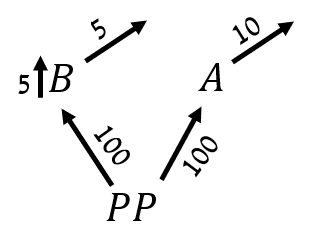

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0],
    1: [0, 0, 0, 0],
    2: [100, 0, 0, 0],
    3: [100, 0, 0, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A',
    3: 'B'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular']
groups_df['q'] = [200, 0, 100, 100]
groups_df['p'] = [200, 0, 10, 10]
groups_df['catch'] = [0, 0, 10, 5]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 0, 0, 5]
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = 0
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

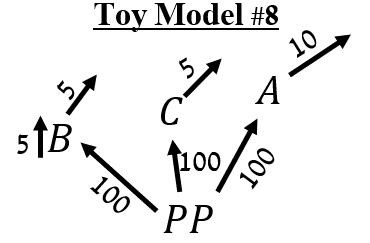

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0, 0],
    1: [0, 0, 0, 0, 0],
    2: [100, 0, 0, 0, 0],
    3: [100, 0, 0, 0, 0],
    4: [100, 0, 0, 0, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A',
    3: 'B',
    4: 'C'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B', 'C']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular', 'Regular']
groups_df['q'] = [300, 0, 100, 100, 100]
groups_df['p'] = [300, 0, 10, 10, 5]
groups_df['catch'] = [0, 0, 10, 5, 5]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 0, 0, 5, 0]
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = 0
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

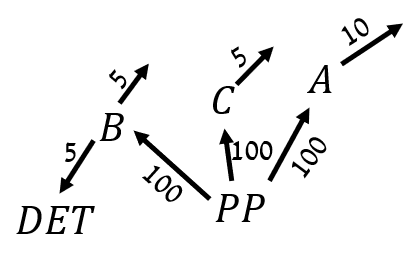

In [ ]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0, 0],
    1: [0, 0, 0, 0, 0],
    2: [100, 0, 0, 0, 0],
    3: [100, 0, 0, 0, 0],
    4: [100, 0, 0, 0, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A',
    3: 'B',
    4: 'C'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B', 'C']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular', 'Regular']
groups_df['q'] = [300, 5, 100, 100, 100]
groups_df['p'] = [300, 5, 10, 10, 5]
groups_df['catch'] = [0, 0, 10, 5, 5]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [0, 5, 0, 0, 0]
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [0, 0, 0, 5, 0]
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

In [ ]:
self.is_model_balanced()

### Real Models

In [ ]:
# model_number = 227  # few %, now smaller
# model_number = 240  # ~20%, now ~10%
# model_number = 242  # ~40%, now ~3%
# model_number = 282  # ~20%, now 0%.
# model_number = 413  # ~5%
# model_number = 487  # ~10%, now <1%
# model_number = 687  # ~0.1%
# model_number = 496  # 125%, did not change
model_number = 7  # 
# model_number = 473  # Calvi Bay 1998
# model_number = 468  # Black Sea
# model_number = 168
# model_number = 2
# model_number = 153
# model_number = 172
# model_number = 503
# model_number = 646  # Guinea 1998
# model_number = 651  # Mauritania 1998

self = PPRCalculator(model_number)

## Tests

In [ ]:
sppr, A, L = self.SPPR_new(TE=None, TE_option='TE', DET_TE_vals=1)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr.round(2)

In [ ]:
TE_option = 'TE'
TL = self.get_TL(break_cycles=False, DET_as_PP=False, TE_option=TE_option)
TE = self.get_TE(TE_option=TE_option, as_matrix=False)
TL, TE = PPRCalculator.rename_results([TL, TE], self.seq2name)
# TL.sort_values().round(3)
# TE.sort_values().round(5)
# TE.sort_values()
# (self.p - self.M0).sort_values().round(3).rename(index=self.seq2name)
# ee = (self.net_migration + self.growth + self.predation + self.catch) / (self.M0 + self.net_migration + self.growth + self.predation + self.catch)
# (self.EE - ee).sort_values().round(3).rename(index=self.seq2name)
# (ee).sort_values().round(3).rename(index=self.seq2name)
self.get_DC(DET_as_PP=False).sum(axis=1)

## SPPR calculations

#### old

In [ ]:
sppr = self.SPPR_1986()
sppr = PPRCalculator.rename_results(sppr, self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
sppr.sum(axis=1)
sppr

In [ ]:
sppr = self.SPPR_1995(global_TE=0.1)
sppr = PPRCalculator.rename_results(sppr, self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr

In [ ]:
sppr = self.SPPR_1995(global_TE='mean')
sppr = PPRCalculator.rename_results(sppr, self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
sppr.sum(axis=1)
sppr

In [ ]:
sppr = self.SPPR_1995_TL_fix(global_TE='mean')
sppr = PPRCalculator.rename_results(sppr, self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
sppr.sum(axis=1)
sppr

#### EwE

In [ ]:
sppr, A, L = self.SPPR_EwE_Ido(TE_option='TE', global_TE='mean', use_EE=True)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr, only_inner=True).rename(columns=self.seq2name).sum(axis=1))
print(self.get_PPR(sppr, only_inner=False).rename(columns=self.seq2name).sum(axis=1))
print(self.get_PPR(sppr).rename(columns=self.seq2name))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
sppr.sum(axis=1).round(4).rename(index=self.name2seq).sort_index().rename(index=self.seq2name)
# sppr

#### 2015

In [ ]:
# sppr, A, L = self.original_model.SPPR_2015(only_pp_det=True)
sppr, A, L = self.SPPR_2015(only_pp_det=True)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr

#### new

In [ ]:
sppr, A, L = self.SPPR_new(TE=None, TE_option='TE', DET_TE_vals=1)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr, only_inner=True).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
sppr.sum(axis=1)
# sppr

In [ ]:
sppr, A, L = self.SPPR_new(TE=None, TE_option='GE', DET_TE_vals=1)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
# sppr.sum(axis=1)
# sppr

In [ ]:
sppr, A, L = self.SPPR_new(TE=None, TE_option='With Egestion', DET_TE_vals=1)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
# sppr.sum(axis=1)
sppr

In [ ]:
sppr, A, L = self.SPPR_new(TE=None, TE_option='With Egestion', DET_TE_vals=1)
# sppr, A, L = SPPR_new(self, TE=None, TE_option='GE', DET_TE_vals=1)
# sppr, A, L = SPPR_new(self, TE=None, TE_option='TE', DET_TE_vals=1)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr

#### symbolic

In [ ]:
sppr_symbolic, sppr, equations, variabls = self.SPPR_symbolic(TE=None, TE_option='TE', diet_import_option='as_PP', DET_TE_vals=1)
sppr_symbolic, sppr, equations, variabls = PPRCalculator.rename_results([sppr_symbolic, sppr, equations, variabls], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr

In [ ]:
sppr_symbolic, sppr, equations, variabls = self.SPPR_symbolic(TE=None, TE_option='TE', diet_import_option='as_DC', DET_TE_vals=1)
sppr_symbolic, sppr, equations, variabls = PPRCalculator.rename_results([sppr_symbolic, sppr, equations, variabls], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr, diet_import_equations=(equations, variabls))}')
# sppr.sum(axis=1)
sppr

In [ ]:
sppr_symbolic, sppr, equations, variabls = self.SPPR_symbolic(TE=None, TE_option='GE', diet_import_option='as_PP', DET_TE_vals=1)
sppr_symbolic, sppr, equations, variabls = PPRCalculator.rename_results([sppr_symbolic, sppr, equations, variabls], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr

In [ ]:
sppr_symbolic, sppr, equations, variabls = self.SPPR_symbolic(TE=None, TE_option='GE', diet_import_option='as_DC', DET_TE_vals=1)
sppr_symbolic, sppr, equations, variabls = PPRCalculator.rename_results([sppr_symbolic, sppr, equations, variabls], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr, diet_import_equations=(equations, variabls))}')
# sppr.sum(axis=1)
sppr

In [ ]:
sppr_symbolic, sppr, equations, variabls = self.SPPR_symbolic(TE=None, TE_option='With Egestion', diet_import_option='as_PP', DET_TE_vals=1)
sppr_symbolic, sppr, equations, variabls = PPRCalculator.rename_results([sppr_symbolic, sppr, equations, variabls], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr

In [ ]:
sppr_symbolic, sppr, equations, variabls = self.SPPR_symbolic(TE=None, TE_option='With Egestion', diet_import_option='as_DC', DET_TE_vals=1)
sppr_symbolic, sppr, equations, variabls = PPRCalculator.rename_results([sppr_symbolic, sppr, equations, variabls], self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr, diet_import_equations=(equations, variabls))}')
sppr
# sppr.sum(axis=1)

#### monte carlo

In [ ]:
sppr, _, _, e, v = self.monte_carlo_SPPR(
            n_samples=100, TE_error_percent=10, TE_error_cut_percent=20, kind='symbolic', TE_option='GE', silent=False,
            diet_import_option='as_DC'
            )
sppr = sppr.rename(index=self.seq2name, columns=self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
# print(f'balanced: {self.is_sppr_balanced(sppr, diet_import_equations=(e, v))}')
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr